Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       open      high       low     close        volume merge_date
0  93347.59  94960.91  92743.63  94383.59   6871.738482 2025-01-01
1  94383.59  97776.99  94177.00  96903.19  10912.473840 2025-01-02
2  96905.48  98969.92  96016.63  98136.51   9021.885382 2025-01-03
3  98139.85  98761.02  97516.65  98209.85   2742.089606 2025-01-04
4  98209.85  98814.00  97250.00  98345.33   2377.921759 2025-01-05

Best lag order (AIC):
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -14.32      -14.24   6.041e-07      -14.29
1       -31.02     -30.57*   3.368e-14     -30.84*
2       -30.98      -30.16   3.497e-14      -30.65
3      -31.06*      -29.86  3.241e-14*      -30.58
4       -30.98      -29.40   3.530e-14      -30.34
5       -30.96      -29.01   3.593e-14

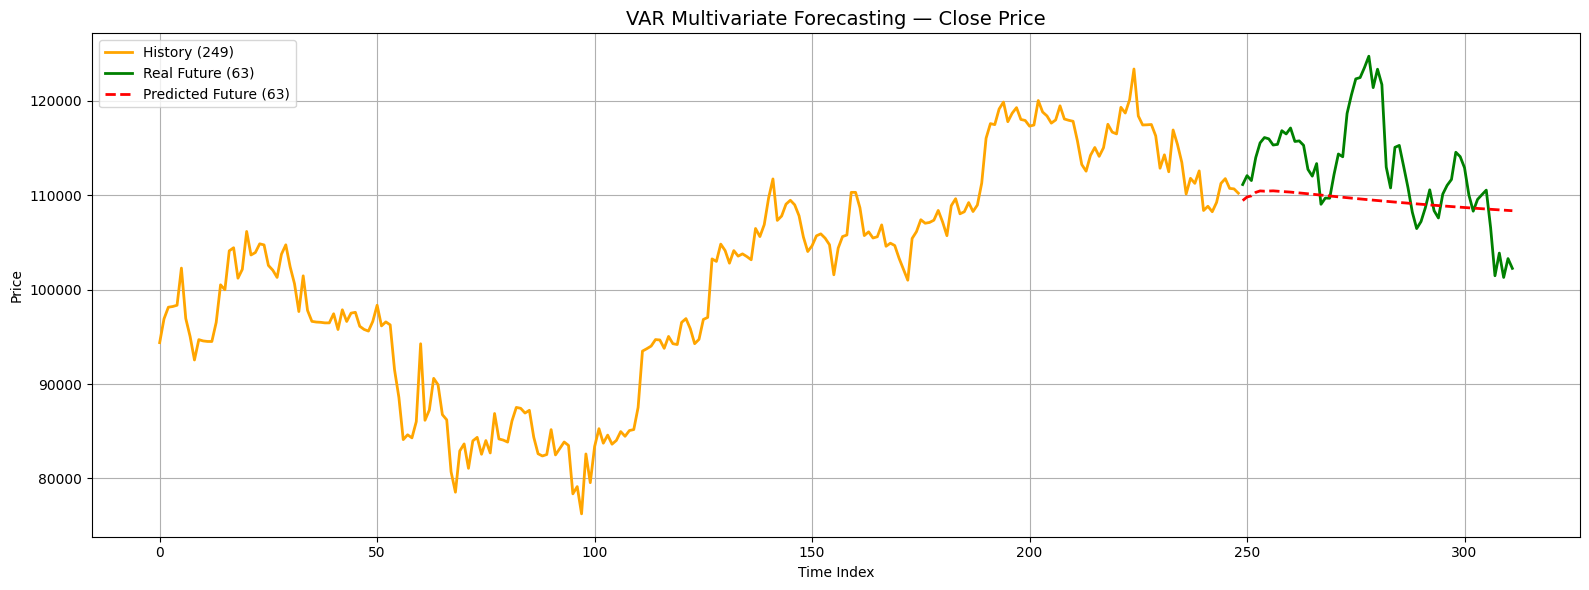

In [3]:
# -*- coding: utf-8 -*-
# ================================================
#     VAR Multivariate Time-Series Forecasting
#     HISTORY = 249, FORECAST = 63
# ================================================

!pip install -q statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------
# 1) خواندن دیتای واقعی
# ------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/data/FINAL SELECTED DATA SET/Bitcoin.csv',
    sep=';',
    parse_dates=['merge_date'],
    dayfirst=True
)

print(df.head())

# ------------------------------------------------
# 2) انتخاب 5 ویژگی اصلی
# ------------------------------------------------
data = df[['open', 'high', 'low', 'close', 'volume']].astype(float)

HISTORY = 249
FORECAST = 63

history_data = data.iloc[:HISTORY, :]
real_future = data.iloc[HISTORY:HISTORY+FORECAST, :]

# ------------------------------------------------
# 3) StandardScaler (اختیاری)
# ------------------------------------------------
scaler = StandardScaler()
history_scaled = scaler.fit_transform(history_data)

df_scaled = pd.DataFrame(
    history_scaled,
    columns=['open', 'high', 'low', 'close', 'volume']
)

# ------------------------------------------------
# 4) ساخت مدل VAR
# ------------------------------------------------
model = VAR(df_scaled)
lag_order = model.select_order(maxlags=20)
print("\nBest lag order (AIC):")
print(lag_order.summary())

best_lag = lag_order.aic
print(f"\nUsing lag = {best_lag}")

var_model = model.fit(best_lag)

# ------------------------------------------------
# 5) پیش‌بینی 63 گام آینده
# ------------------------------------------------
forecast_scaled = var_model.forecast(
    y=df_scaled.values[-best_lag:],
    steps=FORECAST
)

forecast = scaler.inverse_transform(forecast_scaled)

# ------------------------------------------------
# 6) استخراج ستون close برای رسم
# ------------------------------------------------
pred_close = forecast[:, 3]         # ستون close
history_close = history_data['close'].values
real_future_close = real_future['close'].values

# ------------------------------------------------
# 7) رسم تمیز و پیوسته: تاریخچه + آینده واقعی + پیش‌بینی
# ------------------------------------------------
plt.figure(figsize=(16,6))

# تاریخچه
plt.plot(np.arange(HISTORY), history_close, label='History (249)', linewidth=2, color='orange')

# آینده واقعی
plt.plot(np.arange(HISTORY, HISTORY+FORECAST), real_future_close, label='Real Future (63)', linewidth=2, color='green')

# آینده پیش‌بینی
plt.plot(np.arange(HISTORY, HISTORY+FORECAST), pred_close, '--', label='Predicted Future (63)', linewidth=2, color='red')

plt.title("VAR Multivariate Forecasting — Close Price", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
